# **Meaningful Questions**

## 🔍 Meaningful Questions Before Analysis

Before diving into the data, we define the key questions we aim to answer:

1. **Which airline has the highest average departure delay?**
2. **What is the most common reason for flight delays?**
3. **Does flight distance affect departure delay?**
4. **Which airline cancels the most flights?**
5. **What are the most common cancellation reasons?**
6. **Which airports experience the most delays?**
7. **Which routes are most affected by delays?**
8. **Do delays vary by month, day of week, or time of day?**
9. **Are there anomalies in the data (e.g., negative delays, zero air time)?**
10. **What are the main data quality issues we need to address?**

# Data Structure Exploration


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('/content/sample_data/flights_sample_3m.csv')

In [10]:
df.shape

(538067, 32)

In [11]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,1/9/2019,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562.0,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,11/19/2022,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149.0,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,7/22/2022,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459.0,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,3/6/2023,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295.0,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2/23/2020,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407.0,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [12]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [13]:
df.dtypes

,0
FL_DATE,object
AIRLINE,object
AIRLINE_DOT,object
AIRLINE_CODE,object
DOT_CODE,int64
FL_NUMBER,float64
ORIGIN,object
ORIGIN_CITY,object
DEST,object
DEST_CITY,object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538067 entries, 0 to 538066
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  538067 non-null  object 
 1   AIRLINE                  538067 non-null  object 
 2   AIRLINE_DOT              538067 non-null  object 
 3   AIRLINE_CODE             538067 non-null  object 
 4   DOT_CODE                 538067 non-null  int64  
 5   FL_NUMBER                538066 non-null  float64
 6   ORIGIN                   538066 non-null  object 
 7   ORIGIN_CITY              538066 non-null  object 
 8   DEST                     538066 non-null  object 
 9   DEST_CITY                538066 non-null  object 
 10  CRS_DEP_TIME             538066 non-null  float64
 11  DEP_TIME                 524131 non-null  float64
 12  DEP_DELAY                524126 non-null  float64
 13  TAXI_OUT                 523928 non-null  float64
 14  WHEE

# **Descriptive Statistics**

In [15]:
df.describe(include="all")

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,538067,538067,538067,538067,538067.000000,538066.000000,538066,538066,538066,538066,...,538066.000000,538061.000000,522614.000000,522614.000000,538066.000000,96035.000000,96035.000000,96035.000000,96035.000000,96035.000000
unique,1704,18,18,18,NaN,NaN,380,373,379,372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,8/14/2019,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,NaN,NaN,ATL,"Chicago, IL",ATL,"Chicago, IL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,457,102965,102965,102965,NaN,NaN,27579,28131,27666,28618,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,19977.006085,2509.272450,NaN,NaN,NaN,NaN,...,0.002327,142.246030,136.603122,112.287426,809.067284,24.600729,3.873025,13.246056,0.149706,25.486104
std,NaN,NaN,NaN,NaN,377.076332,1745.009596,NaN,NaN,NaN,NaN,...,0.048181,71.447893,71.576316,69.657724,587.009938,71.370030,32.490941,33.446732,3.583937,55.582303
min,NaN,NaN,NaN,NaN,19393.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,20.000000,16.000000,8.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,19790.000000,1051.000000,NaN,NaN,NaN,NaN,...,0.000000,90.000000,84.000000,61.000000,378.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,19930.000000,2151.000000,NaN,NaN,NaN,NaN,...,0.000000,125.000000,120.000000,95.000000,651.000000,4.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,20368.000000,3790.000000,NaN,NaN,NaN,NaN,...,0.000000,172.000000,167.000000,142.000000,1046.000000,23.000000,0.000000,17.000000,0.000000,30.000000


# **Missing Values**

In [16]:
df.isnull().sum()

,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,1
ORIGIN,1
ORIGIN_CITY,1
DEST,1
DEST_CITY,1


In [17]:
df["CANCELLED"].value_counts()

,count
CANCELLED,
0.0,523866
1.0,14200


In [18]:
df["DIVERTED"].value_counts()

,count
DIVERTED,
0.0,536814
1.0,1252


In [19]:
df.dropna(subset=["CRS_ARR_TIME" , "CANCELLED" , "DIVERTED" , 'DISTANCE' , 'AIRLINE_CODE' ,
                  'DOT_CODE'	,'FL_NUMBER' ,'ORIGIN'	,'ORIGIN_CITY', 'DEST'
                  , 'DEST_CITY' ,'CRS_DEP_TIME' , "CRS_ELAPSED_TIME"] , inplace=True)

In [20]:
# the null in the dely columns means "no delay" so replace with 0
delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
df[delay_cols] = df[delay_cols].fillna(0)

In [21]:
df['CANCELLATION_CODE']=df['CANCELLATION_CODE'].fillna("Not Cancelled")

# **Duplicates**

In [22]:
df.duplicated().sum()

np.int64(0)

# **Outlier Detection**

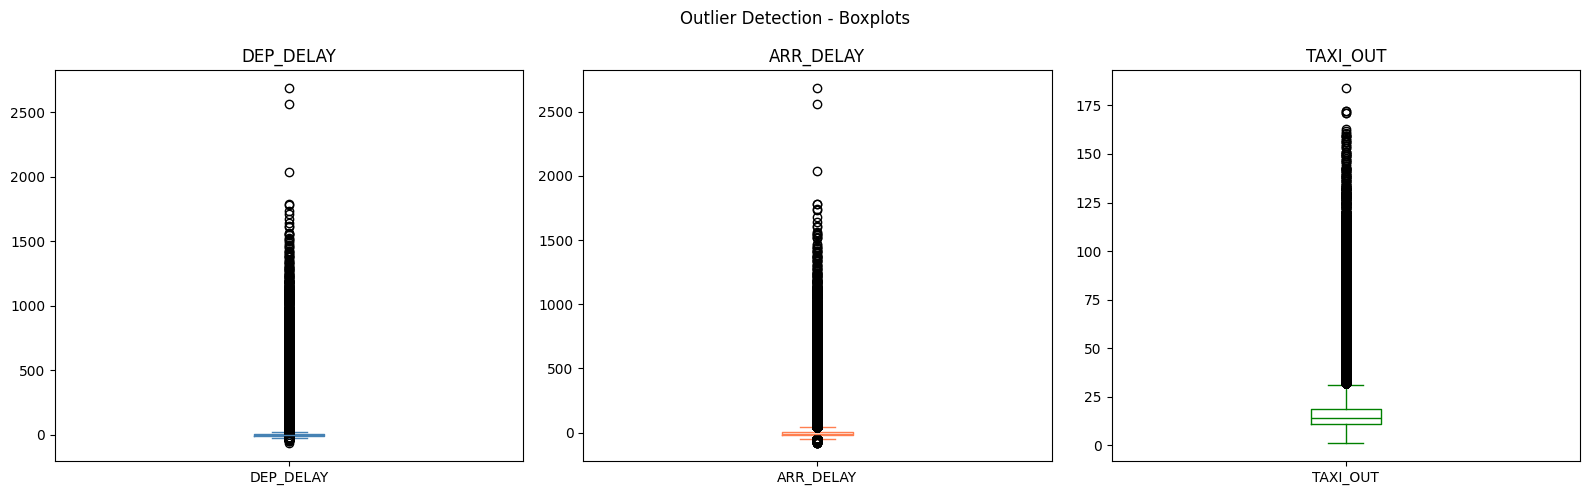

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['DEP_DELAY'].plot(kind='box', ax=axes[0], color='steelblue')
axes[0].set_title('DEP_DELAY')

df['ARR_DELAY'].plot(kind='box', ax=axes[1], color='coral')
axes[1].set_title('ARR_DELAY')

df['TAXI_OUT'].plot(kind='box', ax=axes[2], color='green')
axes[2].set_title('TAXI_OUT')

plt.suptitle('Outlier Detection - Boxplots')
plt.tight_layout()
plt.show()

In [24]:
for col in ['DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'DISTANCE']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

DEP_DELAY: 70649 outliers (13.13%)
ARR_DELAY: 46445 outliers (8.63%)
TAXI_OUT: 29591 outliers (5.50%)
DISTANCE: 30145 outliers (5.60%)


In [25]:
numerical_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns
print("Numerical:", numerical_cols.tolist())
print("Categorical:", categorical_cols.tolist())

Numerical: ['DOT_CODE', 'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
Categorical: ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CANCELLATION_CODE']


In [26]:
categorical_important = ['AIRLINE', 'ORIGIN', 'DEST', 'CANCELLATION_CODE']

for col in categorical_important:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print(f"Unique Values: {df[col].nunique()}")
    print("---")

=== AIRLINE ===
AIRLINE
Southwest Airlines Co.                102964
Delta Air Lines Inc.                   71191
American Airlines Inc.                 68420
SkyWest Airlines Inc.                  61517
United Air Lines Inc.                  45974
Republic Airline                       25666
Envoy Air                              21936
Endeavor Air Inc.                      20237
JetBlue Airways                        20110
PSA Airlines Inc.                      19096
Alaska Airlines Inc.                   17858
Spirit Air Lines                       17367
Frontier Airlines Inc.                 11720
Mesa Airlines Inc.                     11580
Allegiant Air                           9518
Hawaiian Airlines Inc.                  5681
Horizon Air                             3767
ExpressJet Airlines LLC d/b/a aha!      3459
Name: count, dtype: int64
Unique Values: 18
---
=== ORIGIN ===
ORIGIN
ATL    27579
DFW    23320
ORD    21920
DEN    21558
CLT    16940
       ...  
ART        4
OGD  

# **Distribution of Variables**

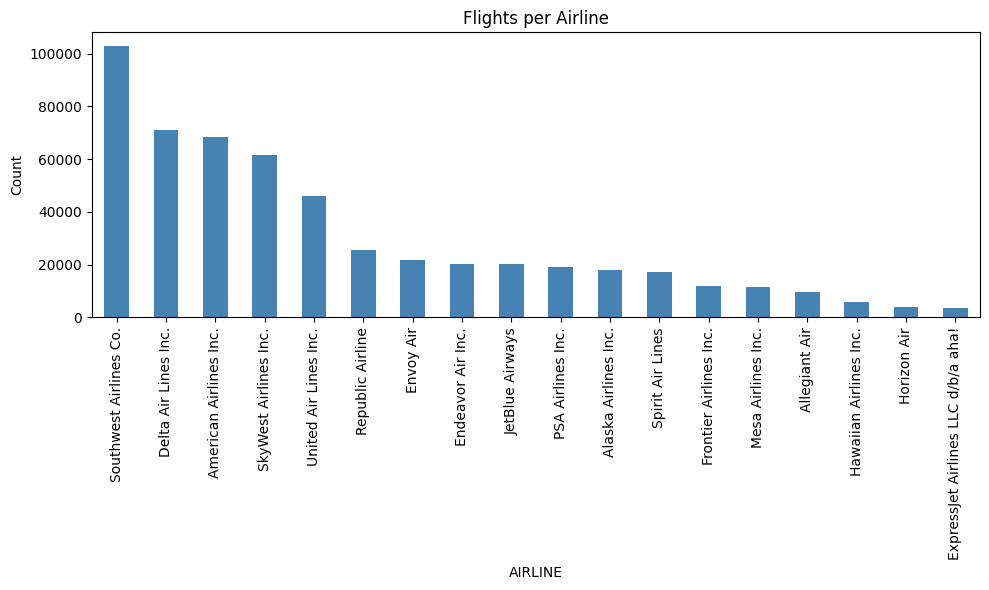

In [27]:
plt.figure(figsize=(10,6))

df['AIRLINE'].value_counts().plot(
    kind='bar',
    color='steelblue'
)

plt.title('Flights per Airline')
plt.xlabel('AIRLINE')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

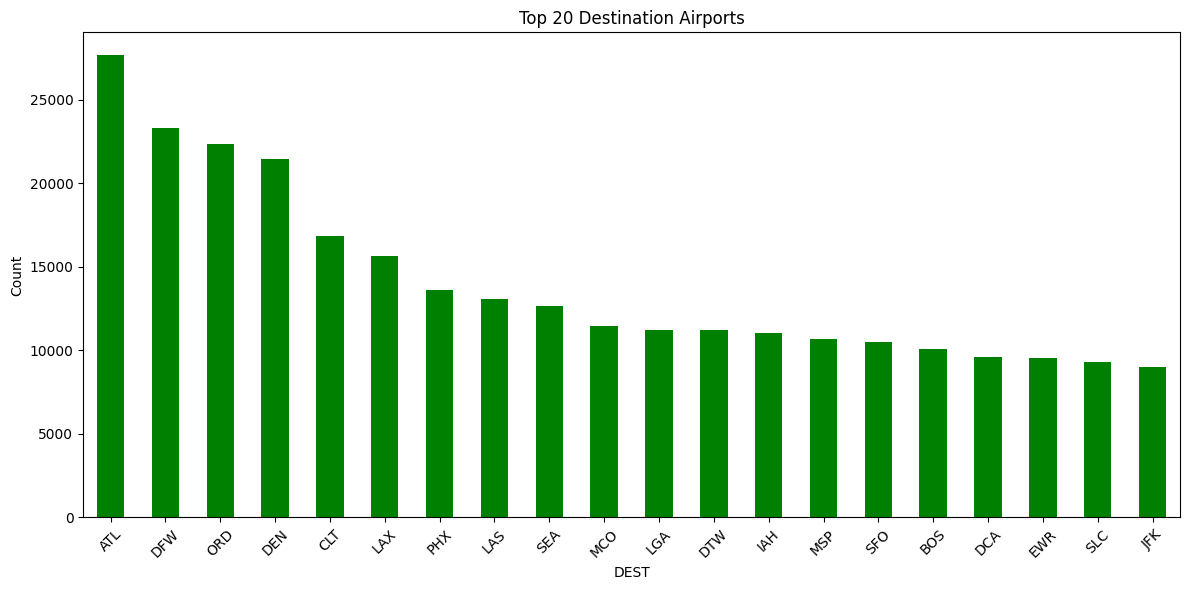

In [28]:
plt.figure(figsize=(12,6))
# TOP 20 DESTINATION
df['DEST'].value_counts().head(20).plot(
    kind='bar',
    color='green'
)

plt.title('Top 20 Destination Airports')
plt.xticks(rotation=45)
plt.xlabel('DEST')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

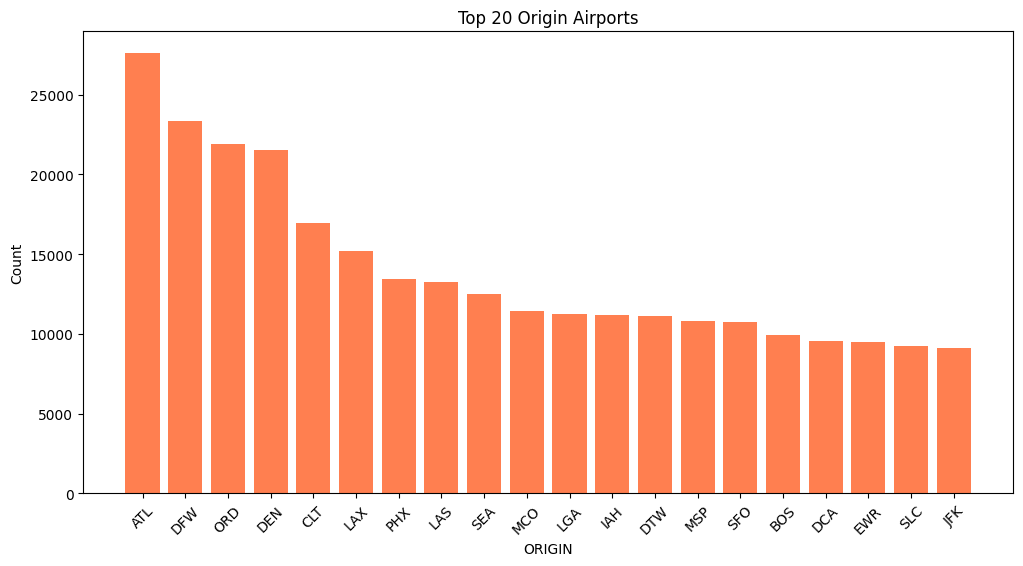

In [29]:
plt.figure(figsize=(12,6))
# TOP 20 ORIGIN
top_origin = df['ORIGIN'].value_counts().head(20)
plt.bar(top_origin.index, top_origin.values, color='coral')
plt.title("Top 20 Origin Airports")
plt.xlabel("ORIGIN")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

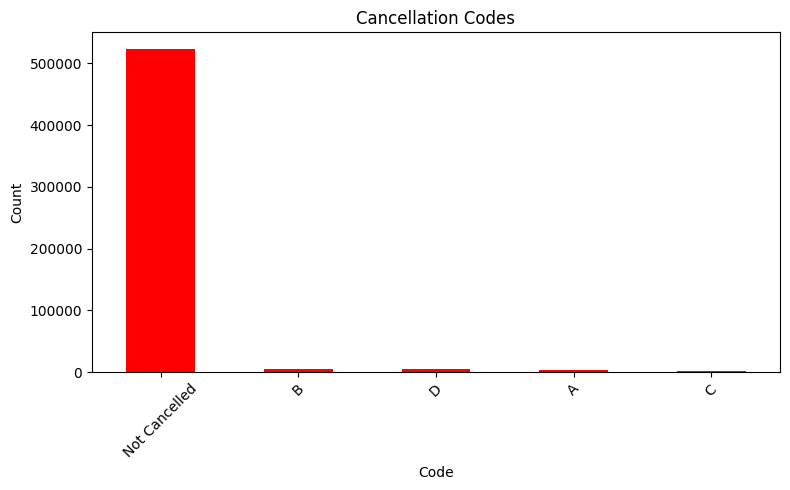

In [30]:
plt.figure(figsize=(8,5))
# CANCELLATION CODE
df['CANCELLATION_CODE'].value_counts().plot(
    kind='bar',
    color='red'
)
plt.title('Cancellation Codes')
plt.xticks(rotation=45)
plt.xlabel('Code')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [31]:
numerical_important = ['DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'TAXI_IN',
                       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME',
                       'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
                       'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

df[numerical_important].describe()

,DEP_DELAY,ARR_DELAY,TAXI_OUT,TAXI_IN,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,524126.00000,522614.000000,523928.000000,523733.000000,538061.000000,522614.000000,522614.000000,538061.000000,538061.000000,538061.000000,538061.000000,538061.000000,538061.000000
mean,10.14552,4.276162,16.645205,7.683856,142.246030,136.603122,112.287426,809.070369,4.390824,0.691271,2.364202,0.026720,4.548849
std,49.11414,51.063815,9.219790,6.270608,71.447893,71.576316,69.657724,587.011554,31.589056,13.806373,15.013056,1.515195,25.429144
min,-68.00000,-84.000000,1.000000,1.000000,20.000000,16.000000,8.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.00000,-16.000000,11.000000,4.000000,90.000000,84.000000,61.000000,378.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.00000,-7.000000,14.000000,6.000000,125.000000,120.000000,95.000000,651.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.00000,7.000000,19.000000,9.000000,172.000000,167.000000,142.000000,1046.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2690.00000,2685.000000,184.000000,240.000000,685.000000,722.000000,662.000000,5095.000000,2685.000000,1398.000000,1468.000000,291.000000,2010.000000


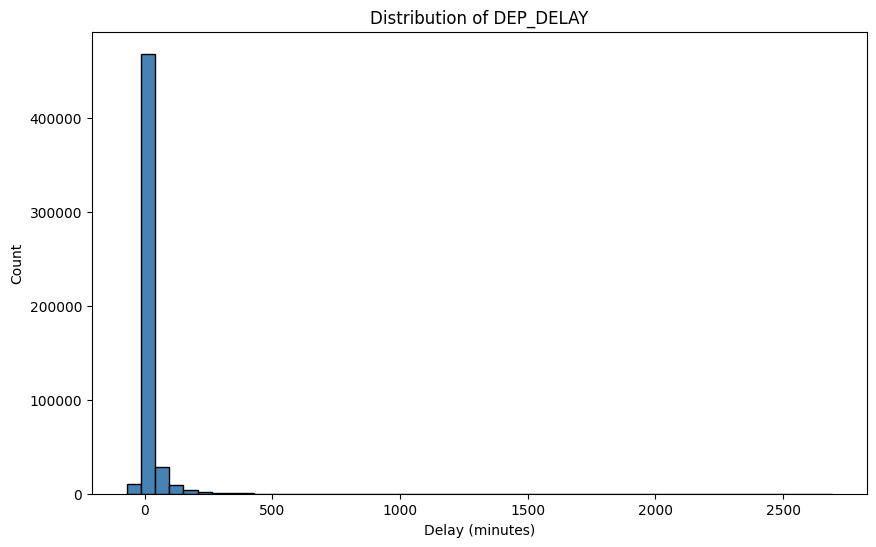

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(df['DEP_DELAY'].dropna(), bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of DEP_DELAY')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.show()
plt.show()

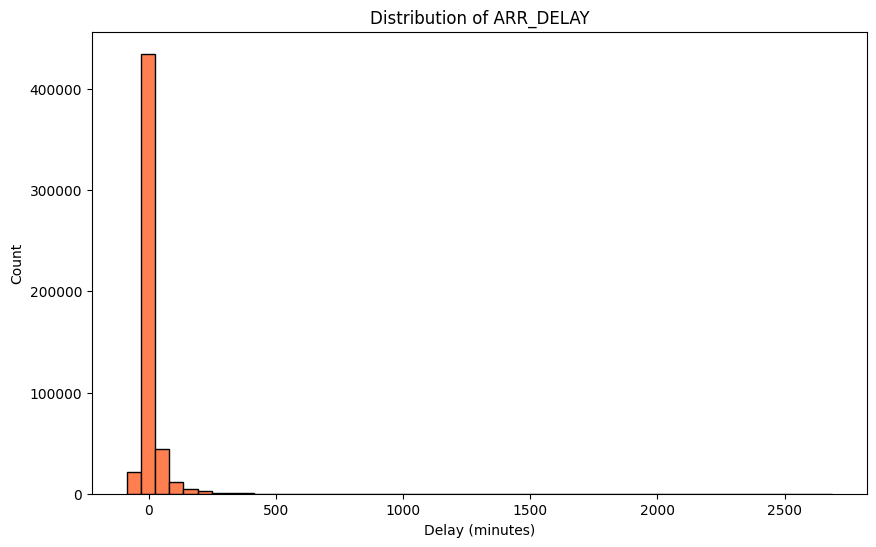

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df['ARR_DELAY'].dropna(), bins=50, color='coral', edgecolor='black')
plt.title('Distribution of ARR_DELAY')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.show()

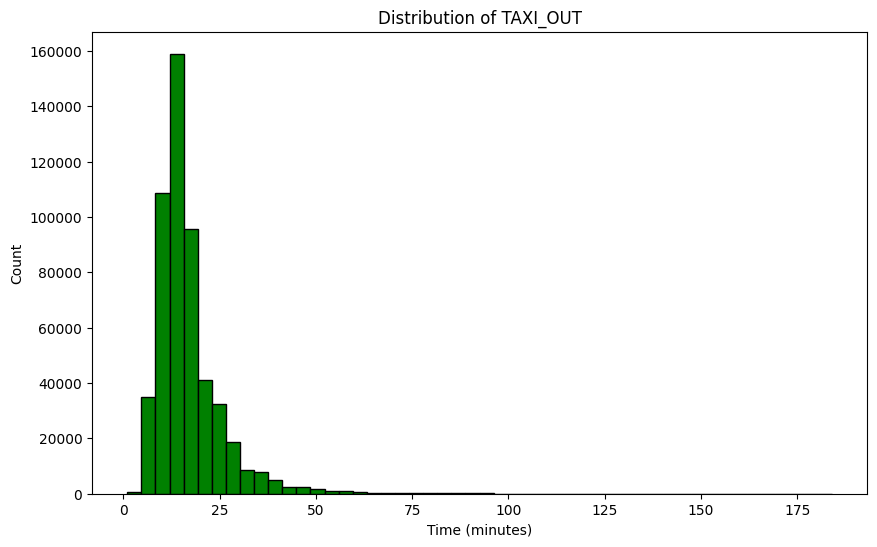

In [34]:
plt.figure(figsize=(10, 6))
plt.hist(df['TAXI_OUT'].dropna(), bins=50, color='green', edgecolor='black')
plt.title('Distribution of TAXI_OUT')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.show()

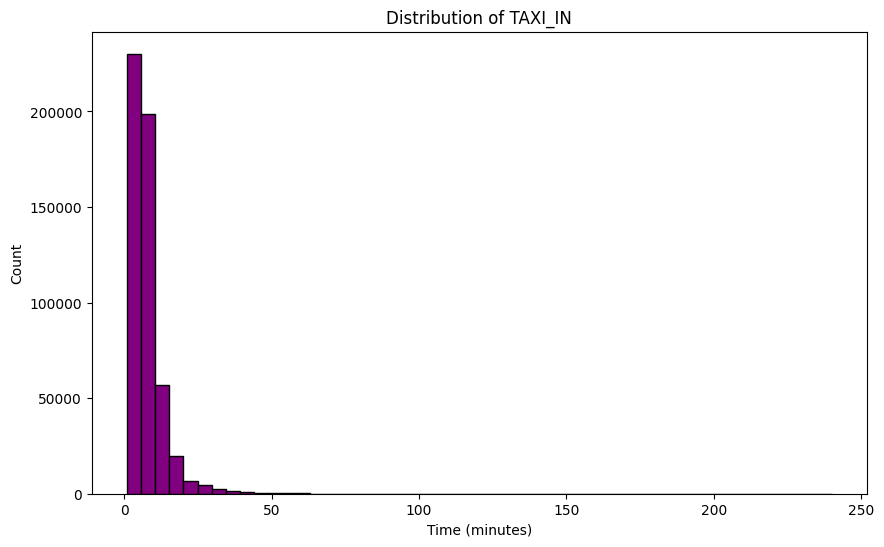

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(df['TAXI_IN'].dropna(), bins=50, color='purple', edgecolor='black')
plt.title('Distribution of TAXI_IN')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.show()


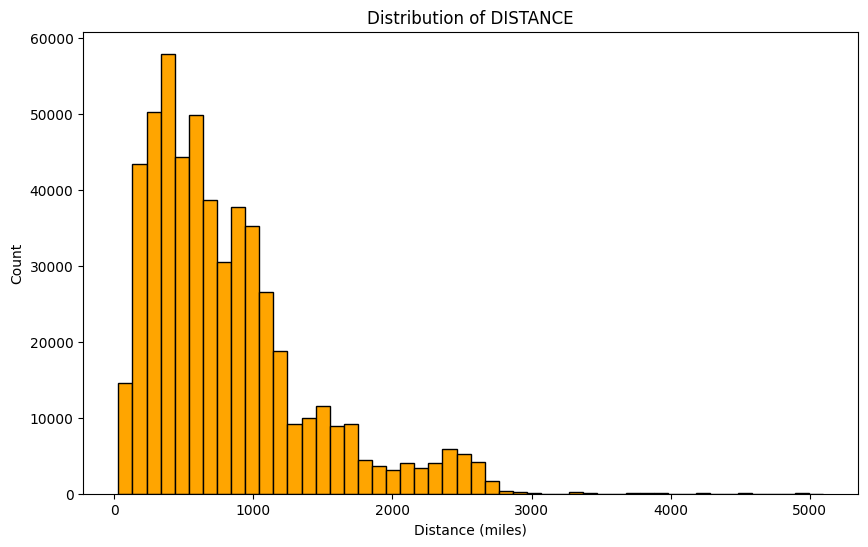

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(df['DISTANCE'].dropna(), bins=50, color='orange', edgecolor='black')
plt.title('Distribution of DISTANCE')
plt.xlabel('Distance (miles)')
plt.ylabel('Count')
plt.show()

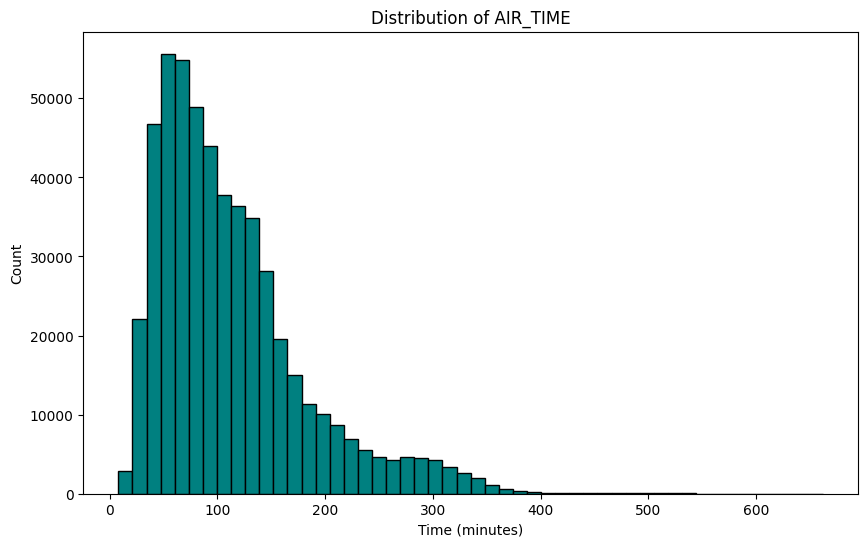

In [39]:
plt.figure(figsize=(10, 6))
plt.hist(df['AIR_TIME'].dropna(), bins=50, color='teal', edgecolor='black')
plt.title('Distribution of AIR_TIME')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.show()


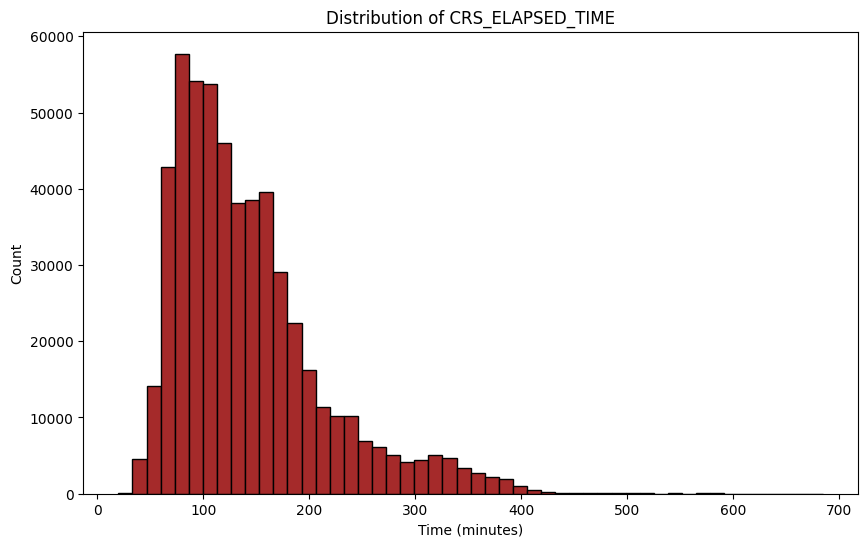

In [38]:
plt.figure(figsize=(10, 6))
plt.hist(df['CRS_ELAPSED_TIME'].dropna(), bins=50, color='brown', edgecolor='black')
plt.title('Distribution of CRS_ELAPSED_TIME')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.show()

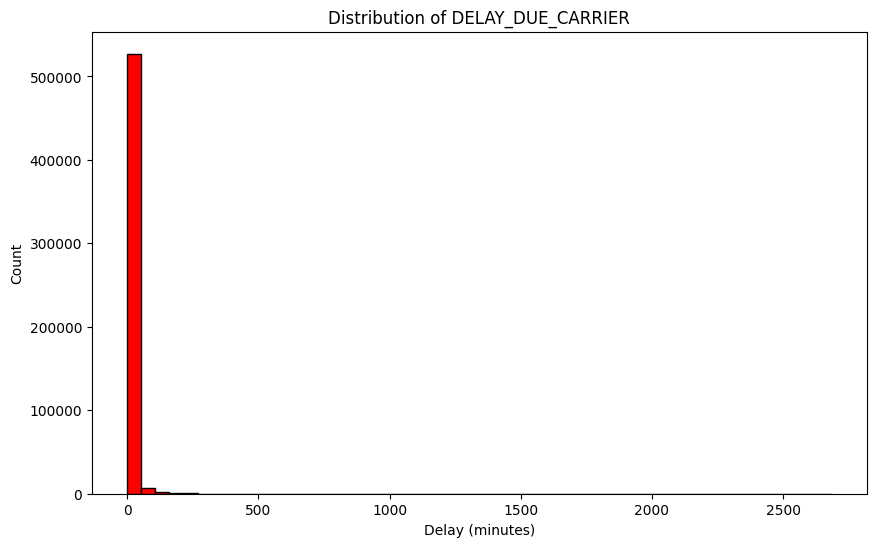

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df['DELAY_DUE_CARRIER'].dropna(), bins=50, color='red', edgecolor='black')
plt.title('Distribution of DELAY_DUE_CARRIER')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.show()

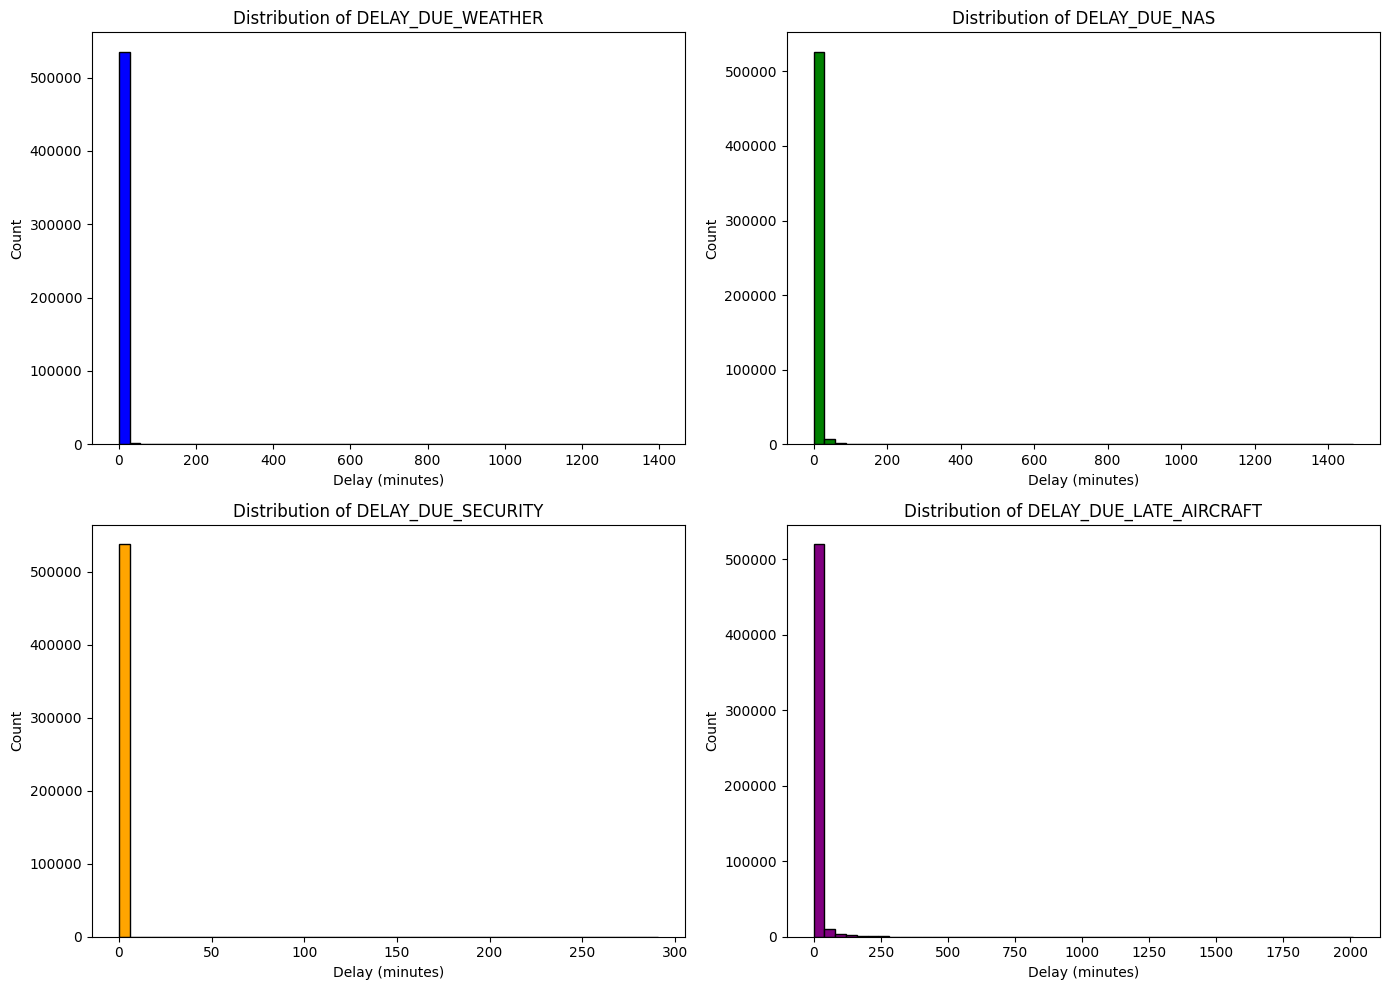

In [36]:
delay_cols = ['DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
              'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['blue', 'green', 'orange', 'purple']

for i, col in enumerate(delay_cols):
    axes[i].hist(df[col].dropna(), bins=50, color=colors[i], edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Delay (minutes)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


# **Correlation Heatmap**

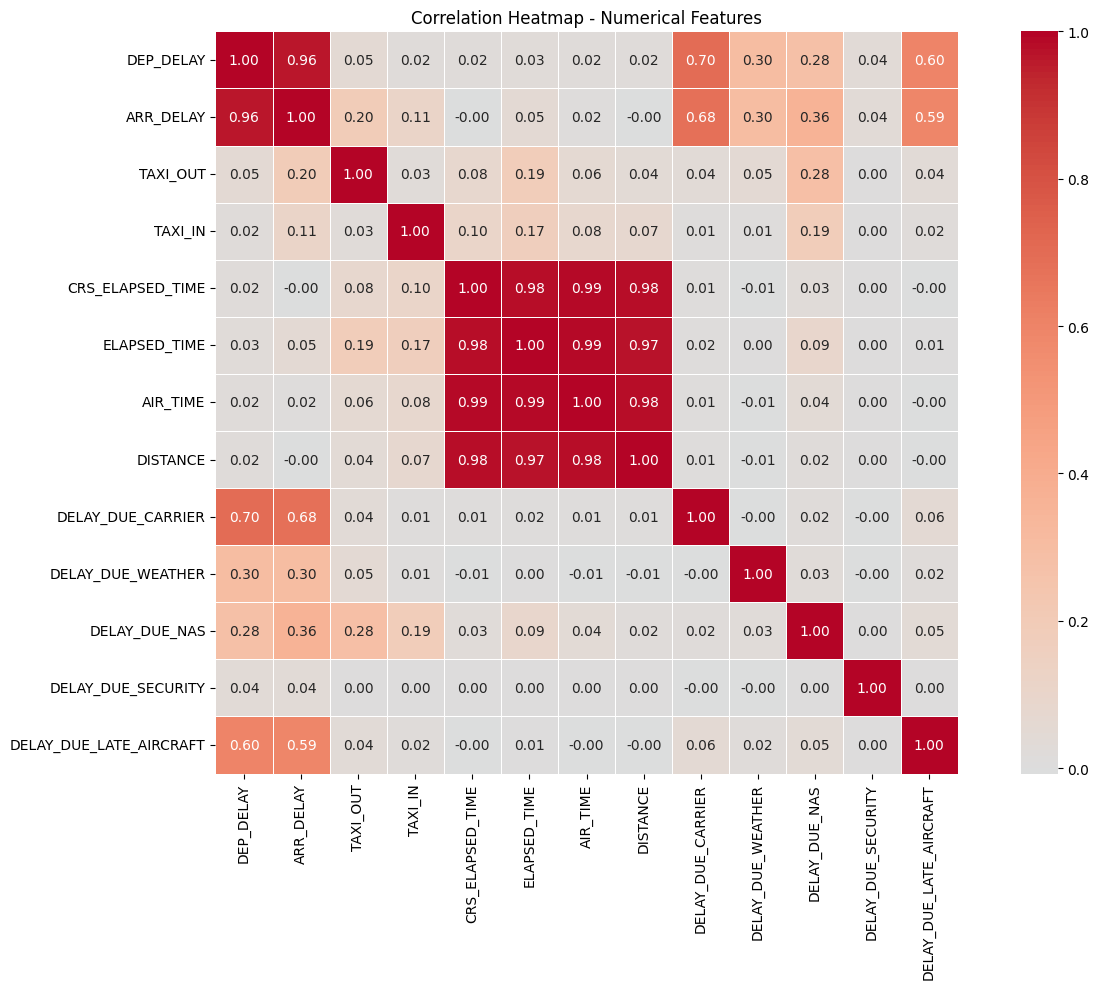

In [58]:
numerical_important = ['DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'TAXI_IN',
                       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME',
                       'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
                       'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

corr_matrix = df[numerical_important].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

In [59]:
# استخراج أعلى الـ correlations
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # شيل الـ self-correlation

print("Top 5 Positive Correlations:")
print(corr_pairs.head(5))
print("\nTop 5 Negative Correlations:")
print(corr_pairs.tail(5))

Top 5 Positive Correlations:
AIR_TIME          CRS_ELAPSED_TIME    0.989157
CRS_ELAPSED_TIME  AIR_TIME            0.989157
ELAPSED_TIME      AIR_TIME            0.987659
AIR_TIME          ELAPSED_TIME        0.987659
DISTANCE          AIR_TIME            0.983831
dtype: float64

Top 5 Negative Correlations:
DELAY_DUE_WEATHER  AIR_TIME            -0.005213
                   CRS_ELAPSED_TIME    -0.005421
CRS_ELAPSED_TIME   DELAY_DUE_WEATHER   -0.005421
DISTANCE           DELAY_DUE_WEATHER   -0.007278
DELAY_DUE_WEATHER  DISTANCE            -0.007278
dtype: float64


# **Insights & Patterns**

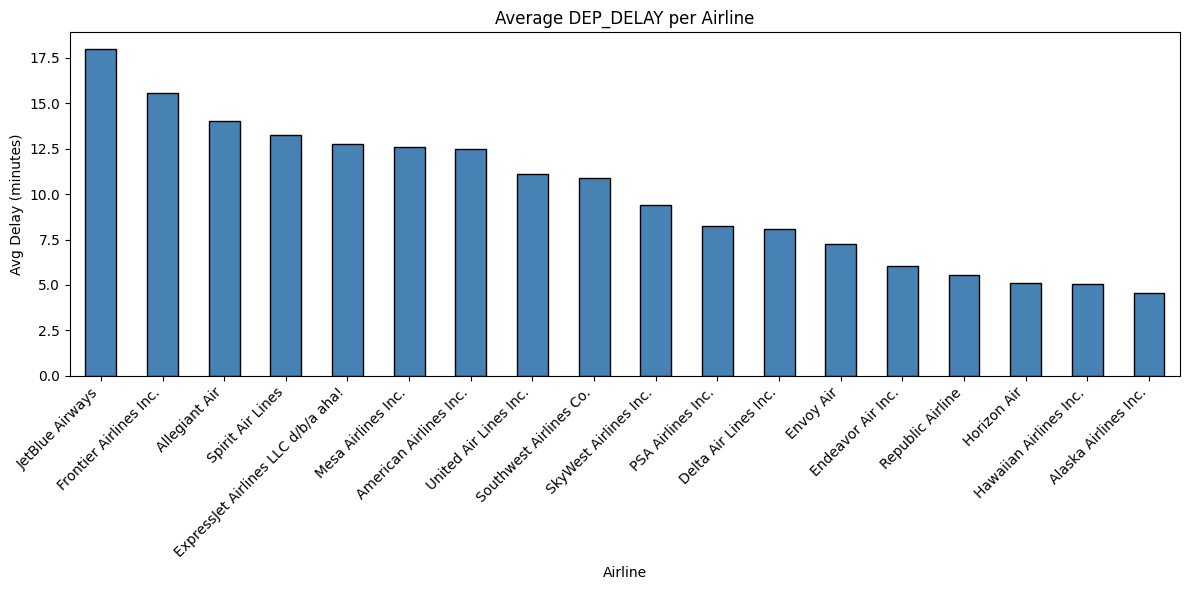

In [43]:
# 1️⃣ إيه الـ Airline الأكتر تأخيراً؟
airline_delay = df[df['CANCELLED'] == 0].groupby('AIRLINE')['DEP_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
airline_delay.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average DEP_DELAY per Airline')
plt.xlabel('Airline')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

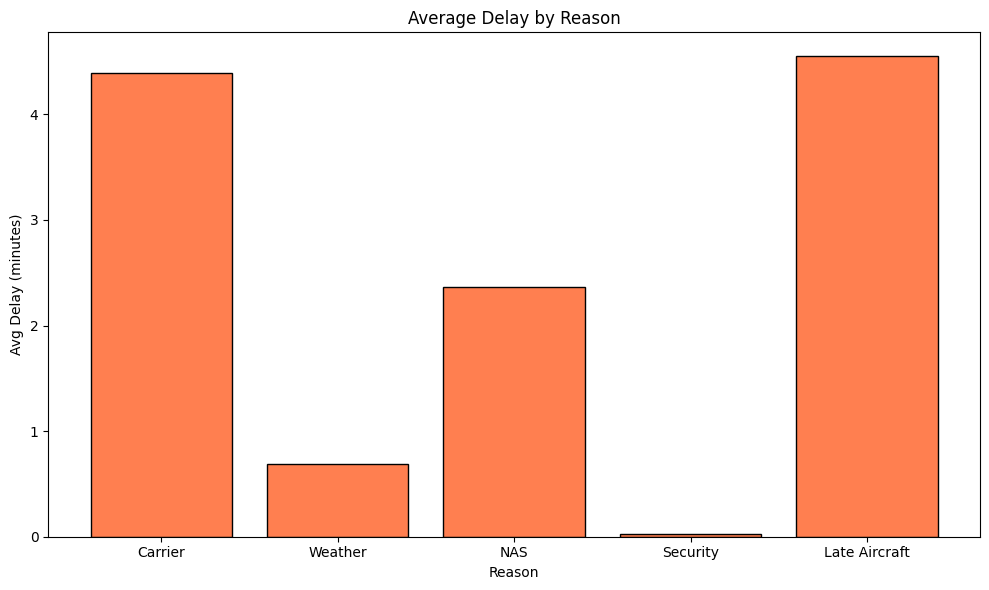

In [44]:
# 2️⃣ إيه أكتر سبب للتأخير؟
delay_reasons = {
    'Carrier': df['DELAY_DUE_CARRIER'].mean(),
    'Weather': df['DELAY_DUE_WEATHER'].mean(),
    'NAS': df['DELAY_DUE_NAS'].mean(),
    'Security': df['DELAY_DUE_SECURITY'].mean(),
    'Late Aircraft': df['DELAY_DUE_LATE_AIRCRAFT'].mean()
}

plt.figure(figsize=(10, 6))
plt.bar(delay_reasons.keys(), delay_reasons.values(), color='coral', edgecolor='black')
plt.title('Average Delay by Reason')
plt.xlabel('Reason')
plt.ylabel('Avg Delay (minutes)')
plt.tight_layout()
plt.show()

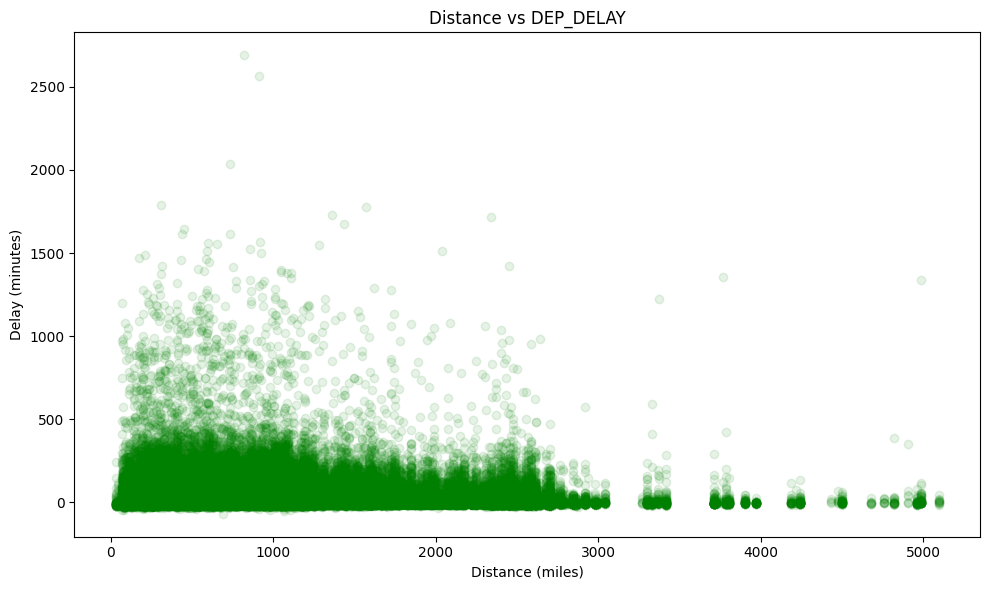

In [45]:
# 3️⃣ هل المسافة بتأثر على التأخير؟
plt.figure(figsize=(10, 6))
plt.scatter(df['DISTANCE'], df['DEP_DELAY'], alpha=0.1, color='green')
plt.title('Distance vs DEP_DELAY')
plt.xlabel('Distance (miles)')
plt.ylabel('Delay (minutes)')
plt.tight_layout()
plt.show()

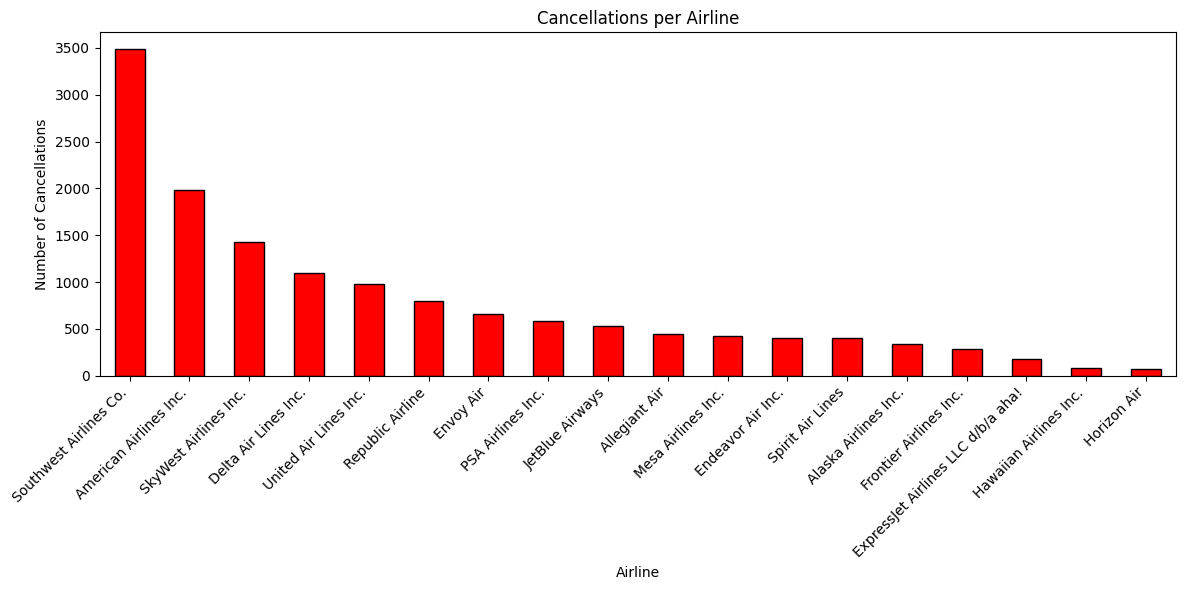

In [46]:
# 4️⃣ إيه الـ Airline الأكتر إلغاءً؟
airline_cancelled = df[df['CANCELLED'] == 1].groupby('AIRLINE')['CANCELLED'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
airline_cancelled.plot(kind='bar', color='red', edgecolor='black')
plt.title('Cancellations per Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

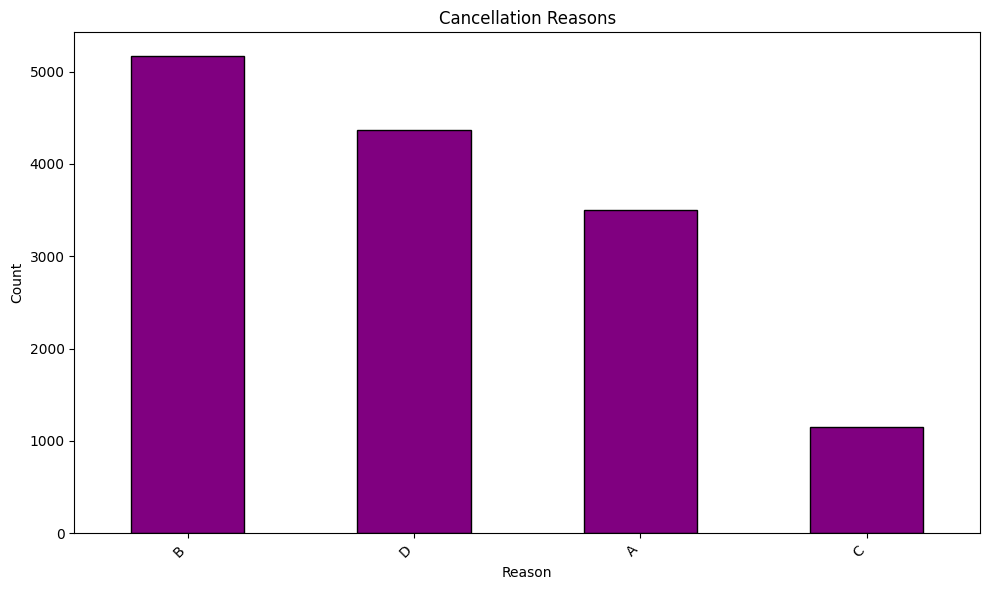

In [47]:
# 5️⃣ إيه أكتر سبب للإلغاء؟
cancel_reasons = df[df['CANCELLED'] == 1]['CANCELLATION_CODE'].value_counts()

plt.figure(figsize=(10, 6))
cancel_reasons.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Cancellation Reasons')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

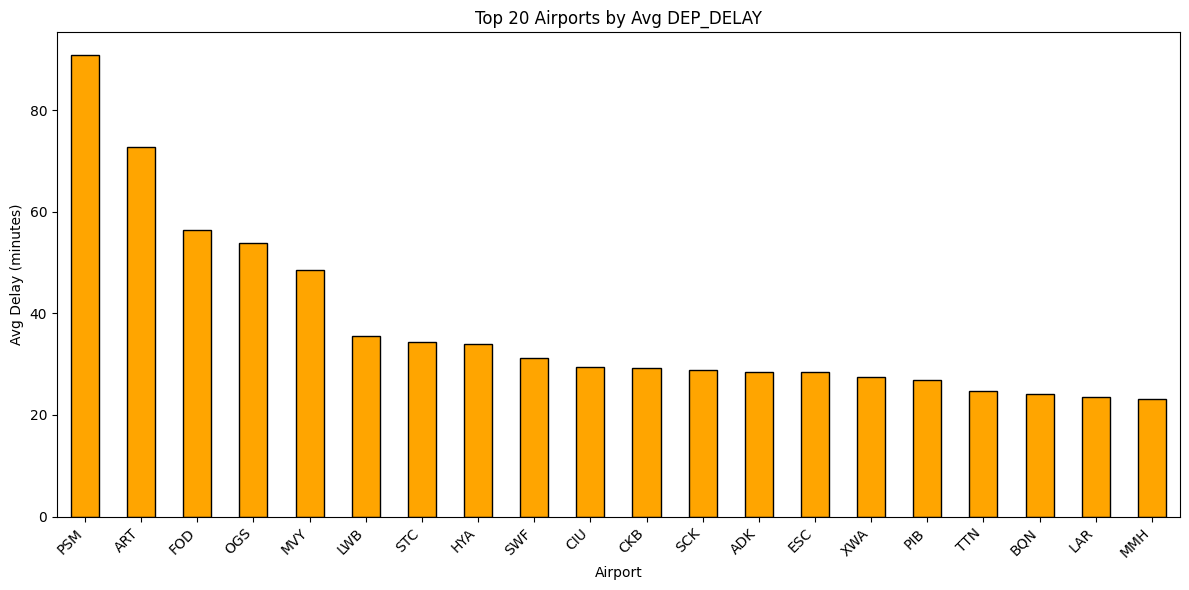

In [48]:
# 6️⃣ إيه أكتر مطار فيه تأخير؟
airport_delay = df[df['CANCELLED'] == 0].groupby('ORIGIN')['DEP_DELAY'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
airport_delay.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 20 Airports by Avg DEP_DELAY')
plt.xlabel('Airport')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

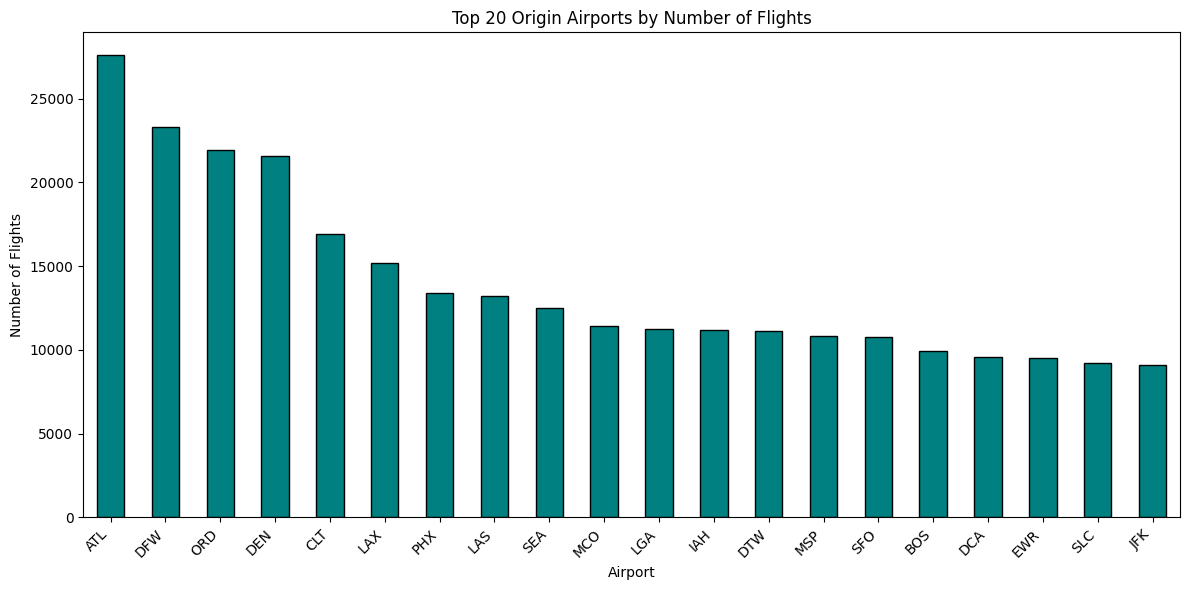

In [49]:
# 7️⃣ إيه أكتر مطار مصدر للرحلات؟
top_origins = df['ORIGIN'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_origins.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 20 Origin Airports by Number of Flights')
plt.xlabel('Airport')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

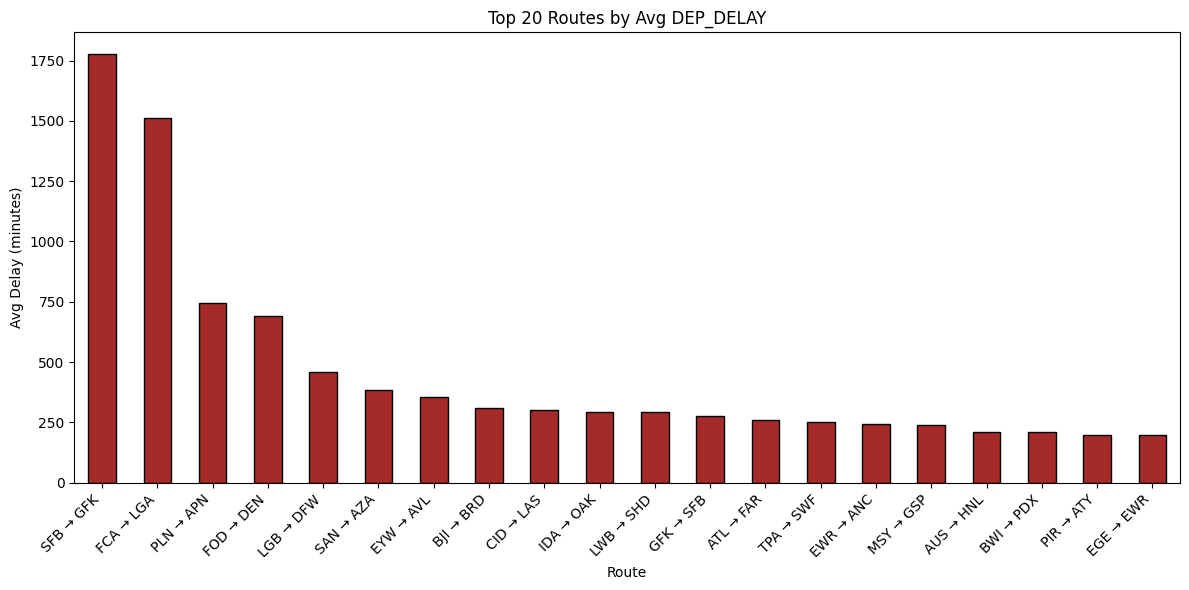

In [50]:
# 8️⃣ إيه الـ Route الأكتر تأخيراً؟
df['ROUTE'] = df['ORIGIN'] + ' → ' + df['DEST']

route_delay = df[df['CANCELLED'] == 0].groupby('ROUTE')['DEP_DELAY'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
route_delay.plot(kind='bar', color='brown', edgecolor='black')
plt.title('Top 20 Routes by Avg DEP_DELAY')
plt.xlabel('Route')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Time-Based Analysis**

In [57]:
df['ROUTE'] = df['ORIGIN'] + ' → ' + df['DEST']

In [56]:
# تحويل التاريخ
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_name()
df['HOUR'] = df['CRS_DEP_TIME'] // 100  # استخراج الساعة من وقت الرحلة

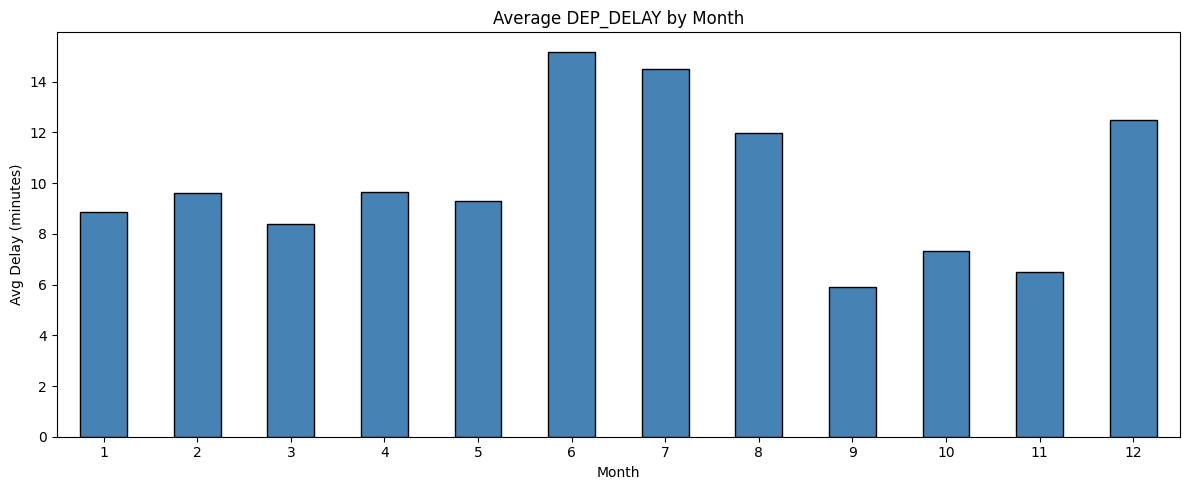

In [53]:
# التأخير بيتغير بالشهر؟
monthly_delay = df.groupby('MONTH')['DEP_DELAY'].mean()

plt.figure(figsize=(12, 5))
monthly_delay.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average DEP_DELAY by Month')
plt.xlabel('Month')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

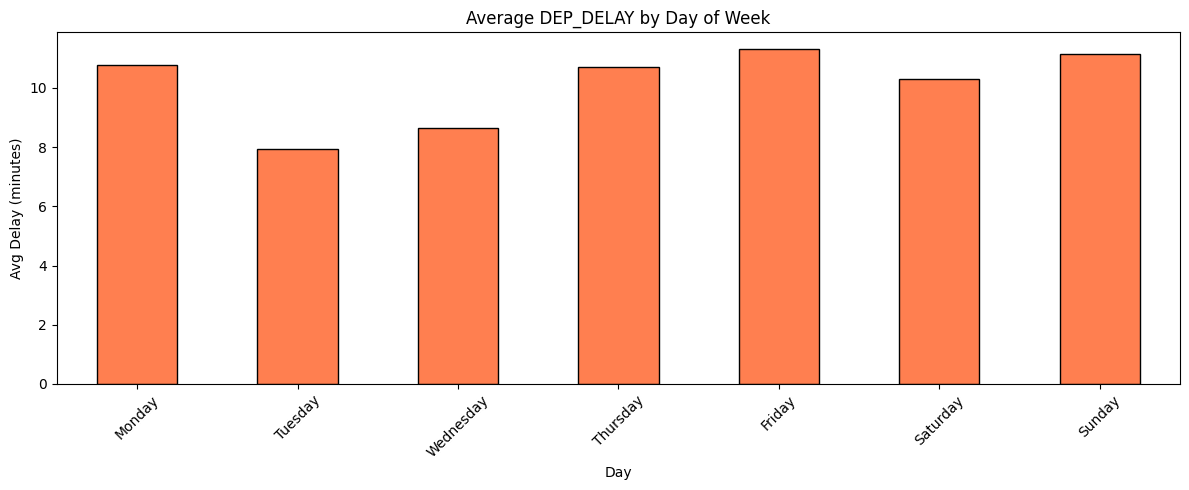

In [54]:
# التأخير بيتغير بيوم الأسبوع؟
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_delay = df.groupby('DAY_OF_WEEK')['DEP_DELAY'].mean().reindex(day_order)

plt.figure(figsize=(12, 5))
dow_delay.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average DEP_DELAY by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

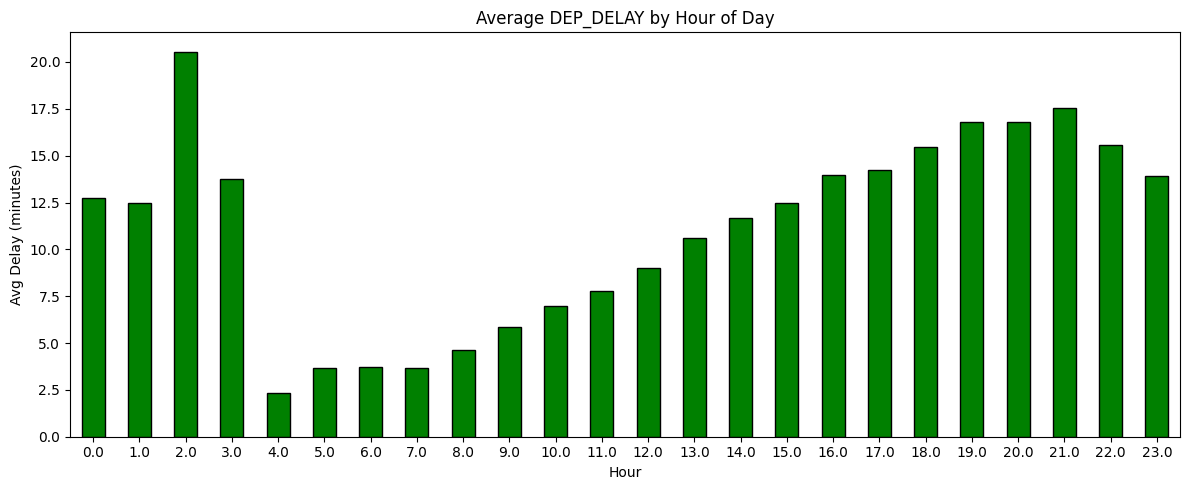

In [55]:
# التأخير بيتغير بالساعة؟
hourly_delay = df.groupby('HOUR')['DEP_DELAY'].mean()

plt.figure(figsize=(12, 5))
hourly_delay.plot(kind='bar', color='green', edgecolor='black')
plt.title('Average DEP_DELAY by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Hypothesis Testing**

In [60]:
# Correlation
correlation = df['DISTANCE'].corr(df['DEP_DELAY'])
print(f"Correlation between DISTANCE and DEP_DELAY: {correlation:.4f}")

Correlation between DISTANCE and DEP_DELAY: 0.0203


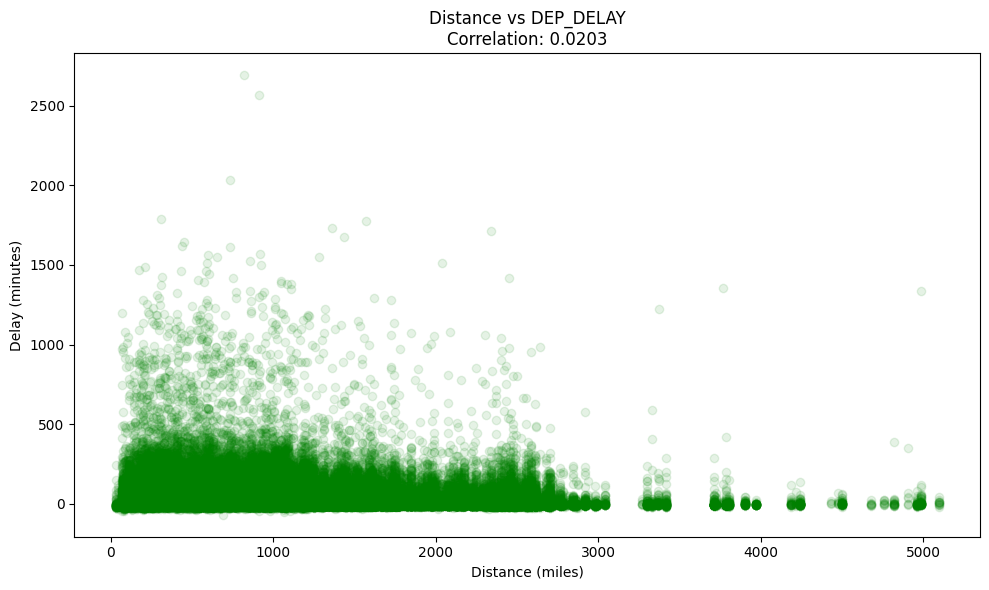

In [61]:
plt.figure(figsize=(10, 6))
plt.scatter(df['DISTANCE'], df['DEP_DELAY'], alpha=0.1, color='green')
plt.title(f'Distance vs DEP_DELAY\nCorrelation: {correlation:.4f}')
plt.xlabel('Distance (miles)')
plt.ylabel('Delay (minutes)')
plt.tight_layout()
plt.show()

In [62]:
# الـ Late Aircraft هو أكتر سبب للتأخير
delay_means = {
    'Carrier': df['DELAY_DUE_CARRIER'].mean(),
    'Weather': df['DELAY_DUE_WEATHER'].mean(),
    'NAS': df['DELAY_DUE_NAS'].mean(),
    'Security': df['DELAY_DUE_SECURITY'].mean(),
    'Late Aircraft': df['DELAY_DUE_LATE_AIRCRAFT'].mean()
}

for reason, mean in sorted(delay_means.items(), key=lambda x: x[1], reverse=True):
    print(f"{reason}: {mean:.4f}")

Late Aircraft: 4.5488
Carrier: 4.3908
NAS: 2.3642
Weather: 0.6913
Security: 0.0267


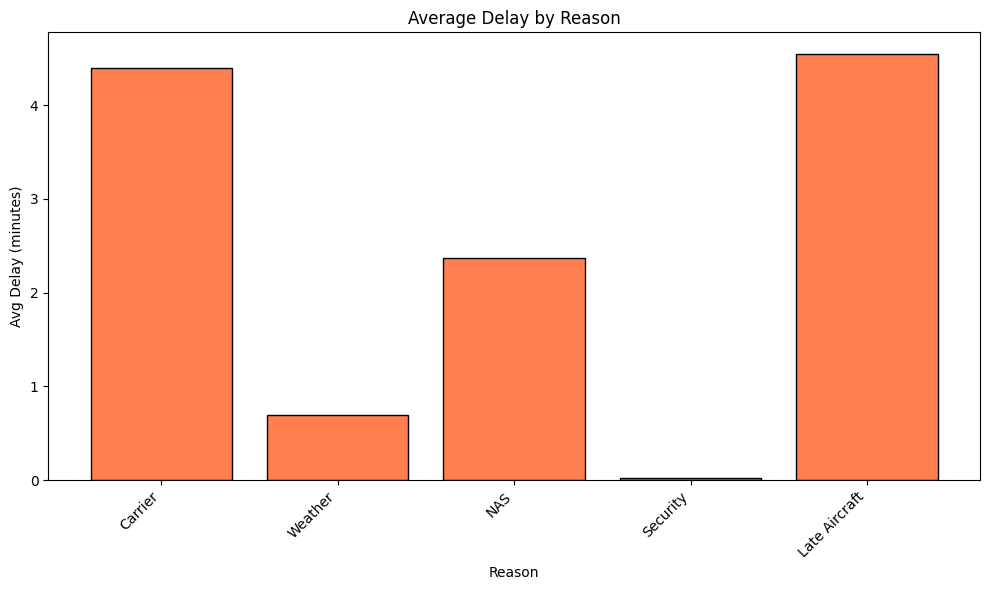

In [63]:
#2️⃣ الـ Late Aircraft هو أكتر سبب للتأخير
plt.figure(figsize=(10, 6))
plt.bar(delay_means.keys(), delay_means.values(), color='coral', edgecolor='black')
plt.title('Average Delay by Reason')
plt.xlabel('Reason')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
#الرحلات الملغاة بتزيد بسبب الطقس
cancel_reasons = df[df['CANCELLED'] == 1]['CANCELLATION_CODE'].value_counts()
cancel_pct = df[df['CANCELLED'] == 1]['CANCELLATION_CODE'].value_counts(normalize=True) * 100

for reason, pct in cancel_pct.items():
    print(f"{reason}: {pct:.2f}%")

B: 36.41%
D: 30.77%
A: 24.68%
C: 8.14%


# **Anomalies & Data Issues**

In [66]:
# رحلات بـ negative delay
neg_dep = df[df['DEP_DELAY'] < 0]
neg_arr = df[df['ARR_DELAY'] < 0]
print(f"Flights with negative DEP_DELAY: {len(neg_dep)} ({len(neg_dep)/len(df)*100:.2f}%)")
print(f"Flights with negative ARR_DELAY: {len(neg_arr)} ({len(neg_arr)/len(df)*100:.2f}%)")

Flights with negative DEP_DELAY: 319663 (59.41%)
Flights with negative ARR_DELAY: 337003 (62.63%)


In [67]:
# رحلات بـ air_time = 0 أو قيم غريبة
zero_airtime = df[df['AIR_TIME'] == 0]
print(f"Flights with AIR_TIME = 0: {len(zero_airtime)}")

# رحلات وقتها الفعلي أكبر من المجدول بفرق كبير
big_diff = df[(df['ELAPSED_TIME'] - df['CRS_ELAPSED_TIME']).abs() > 120]
print(f"Flights with >2hr difference in elapsed time: {len(big_diff)}")

Flights with AIR_TIME = 0: 0
Flights with >2hr difference in elapsed time: 115
